(mmm_campaign_media)=
# Campaign-Granularity MMM with `NestedMediaEffect`

:::{warning}
**VERY EXPERIMENTAL.** The API, priors, and semantics of `NestedMediaEffect` are all subject to change, and `MMM.save`/`load` does not round-trip the effect yet. This notebook demonstrates a draft feature.
:::

Media Mix Models usually stop at the **channel**: one saturation curve per channel, one ROI per channel. But budgets are planned at **campaign** level, and practitioners keep asking the MMM a question it cannot answer: *which campaign inside the channel is pulling the weight?*

Naively splitting a channel into campaigns fails in two opposite ways:

- **No pooling**: each campaign gets its own free parameters. Small campaigns (a 2% spend share is common) have almost no individual signal, so their posteriors are wide and their ROIs are noise.
- **Averaging**: report the channel ROI for every campaign, which is exactly the non-answer we started with.

`NestedMediaEffect` takes the middle road, following three principles:

1. **Hierarchical pooling is the accuracy lever.** Campaign parameters are non-centred deviations under *channel-level* hyperpriors, so weakly-identified campaigns shrink toward their channel instead of chasing noise.
2. **Identification comes from the mix, not from a constraint.** Because $\sum_c f_c(x_c) \neq f(\sum_c x_c)$ for saturating $f$, weeks with different campaign mixes at the same channel total are informative. Flighting variation, dark weeks, per-campaign covariates, and lift tests are the signal sources; without them, campaign efficiency is *unidentified* and the pooling correctly returns the channel mean.
3. **Channel-level ROI must not be destabilised.** Campaign log-multipliers are constrained to a *spend-share-weighted zero sum* within each channel, so the channel-level parameters keep their meaning, and a channel roll-up deterministic is registered for direct comparison.

The effect **replaces** the channel-level media term for the channels it decomposes: those channels must be excluded from `channel_columns` (a `UserWarning` fires otherwise, because keeping both double-counts the spend).

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr

from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.nested_media import NestedMediaEffect

seed = 20260825
rng = np.random.default_rng(seed)
az.style.use("arviz-darkgrid")
dollars = mtick.FuncFormatter(lambda v, _: f"${v / 1e3:,.0f}k")

## Synthetic data with a known answer

Four channels at two granularities. `search` and `tv` stay at channel level, as most channels in a real model will. `social` is decomposed into three campaigns with a lopsided **70/20/10** average spend split, and `display` into two campaigns at 60/40. The ground truth gives the social campaigns efficiencies of **1 : 1.5 : 2**, rising as size falls — precisely the situation where a channel-level MMM is silently wrong and a no-pooling model is too noisy to notice — and the display campaigns **1 : 3**, a large gap in a channel with only two campaigns.

Spends are weekly dollars, roughly $60k for `search`, $100k for `tv` in flights, $40k for `social` and $20k for `display`, against weekly revenue of a few hundred thousand dollars. The campaign spends get lognormal flighting noise and occasional dark weeks: that mix variation is what identifies the split.

/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_24639/1618110905.py:99: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


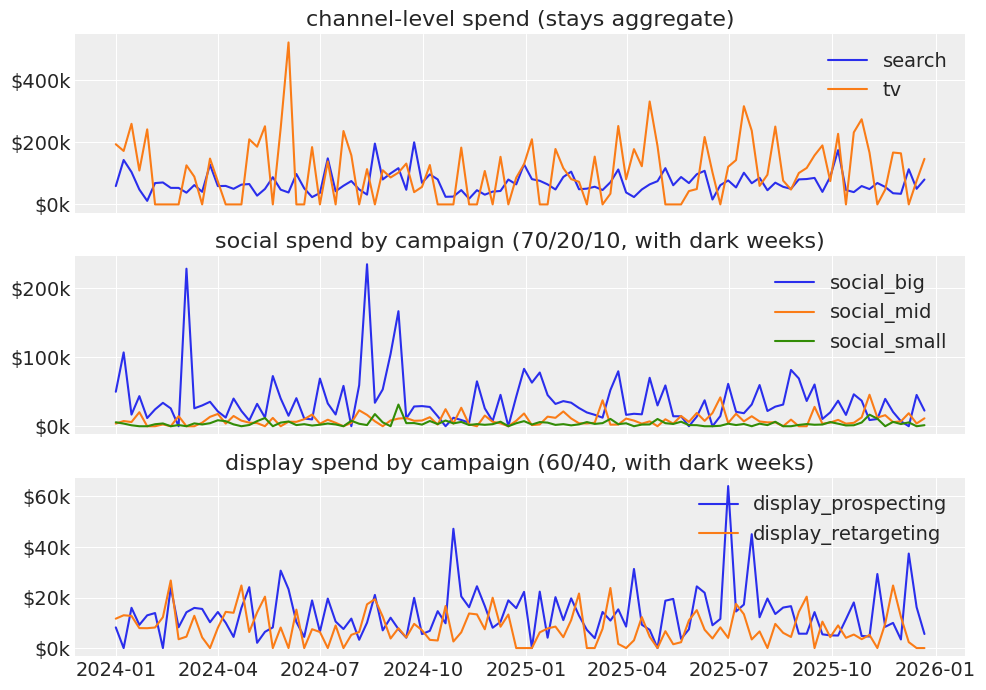

In [2]:
n_dates = 104
dates = pd.date_range("2024-01-01", periods=n_dates, freq="W-MON")

# draw order matters for reproducibility: search and social first (as in the
# single-channel version of this notebook), then the channels added later
# weekly spend in dollars per channel, and the weekly revenue unit of the truth
search_weekly, tv_weekly, social_weekly, display_weekly = (
    60_000,
    100_000,
    40_000,
    20_000,
)
revenue_scale = 250_000

search_spend = search_weekly * rng.lognormal(0, 0.5, n_dates)

social_campaigns = ["social_big", "social_mid", "social_small"]
display_campaigns = ["display_prospecting", "display_retargeting"]
campaigns = social_campaigns + display_campaigns
mapping = {c: "social" for c in social_campaigns} | {
    c: "display" for c in display_campaigns
}
shares = np.array([0.70, 0.20, 0.10])  # social
display_shares = np.array([0.60, 0.40])


def campaign_spends(shares):
    """Lognormal flighting noise around the average split, with dark weeks."""
    spend = shares[None, :] * rng.lognormal(0, 0.7, size=(n_dates, len(shares)))
    for j, s in enumerate(shares):
        spend[rng.random(n_dates) < 0.20 * (1 - s), j] = 0.0
    return spend


social_spend = social_weekly * campaign_spends(shares)
noise = rng.normal(0, 0.08, n_dates)

# two more channels: one stays at channel level, one is split 60/40
tv_spend = tv_weekly * rng.lognormal(0.3, 0.6, n_dates)
tv_spend[rng.random(n_dates) < 0.30] = 0.0  # tv runs in flights
display_spend = display_weekly * campaign_spends(display_shares)
campaign_spend = np.column_stack([social_spend, display_spend])

# ground truth on channel-scaled spend
s_search, s_tv = search_spend.max(), tv_spend.max()
s_social, s_display = social_spend.sum(1).max(), display_spend.sum(1).max()
xs, xt = search_spend / s_search, tv_spend / s_tv
xc, xd = social_spend / s_social, display_spend / s_display
cap, cap_d = xc.max(0), xd.max(0)
true_beta_mult = np.array([1.0, 1.5, 2.0])  # social: efficiency rises as size falls
true_display_mult = np.array([1.0, 3.0])  # display: retargeting is 3x prospecting
contrib_search = revenue_scale * 1.0 * xs / (xs + 0.4)
contrib_tv = revenue_scale * 0.8 * xt / (xt + 0.5)
# size-tied truth: campaign curve = channel curve scaled by cap on both axes
contrib_camp = revenue_scale * (1.2 * true_beta_mult) * cap * xc / (xc + 0.35 * cap)
contrib_display = (
    revenue_scale * (0.6 * true_display_mult) * cap_d * xd / (xd + 0.5 * cap_d)
)
target = (
    revenue_scale * 0.3
    + contrib_search
    + contrib_tv
    + contrib_camp.sum(1)
    + contrib_display.sum(1)
    + revenue_scale * noise
)


def relative_multipliers(mult, spend):
    """Return the multipliers the model can identify.

    Relative to the channel's spend-share-weighted geometric mean, which the
    channel amplitude absorbs.
    """
    w = spend.sum(0) / spend.sum()
    return mult / np.exp(w @ np.log(mult))


true_relative = np.r_[
    relative_multipliers(true_beta_mult, social_spend),
    relative_multipliers(true_display_mult, display_spend),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(dates, search_spend, label="search")
axes[0].plot(dates, tv_spend, label="tv")
axes[0].set_title("channel-level spend (stays aggregate)")
axes[0].legend(loc="upper right")
for j, c in enumerate(social_campaigns):
    axes[1].plot(dates, social_spend[:, j], label=c)
axes[1].set_title("social spend by campaign (70/20/10, with dark weeks)")
axes[1].legend(loc="upper right")
for j, c in enumerate(display_campaigns):
    axes[2].plot(dates, display_spend[:, j], label=c)
axes[2].set_title("display spend by campaign (60/40, with dark weeks)")
axes[2].legend(loc="upper right")
for ax in axes:
    ax.yaxis.set_major_formatter(dollars)
fig.tight_layout()

## Building the model

The `campaign` dimension does not fit the wide-DataFrame API, so `X` is an `xr.Dataset`: the `media` variable carries the channel-level spend, and `campaign_data` rides along with its own `campaign` dimension. Every variable listed in the effect's `data_vars` is read from this Dataset at build time.

Note what is **not** here: `social` and `display` are absent from `channel_columns` — the effect owns them, while `search` and `tv` stay ordinary channels. One effect, one mapping, any number of parents with any number of children each.

One workflow note: `MMM.fit` converts `X` to a long-form `fit_data` frame, which cannot align `y` against a variable carrying the extra `campaign` dimension (the same limitation behind the save/load caveat below). So we call `build_model` and sample inside the model directly — the same pattern the funnel-effect notebook uses.

In [3]:
X = xr.Dataset(
    {
        "media": xr.DataArray(
            np.column_stack([search_spend, tv_spend]), dims=("date", "channel")
        ),
        "campaign_data": xr.DataArray(campaign_spend, dims=("date", "campaign")),
    },
    coords={"date": dates, "channel": ["search", "tv"], "campaign": campaigns},
)
y = xr.DataArray(target, dims=("date",), coords={"date": dates})

mmm = MMM(
    channel_columns=["search", "tv"],
    date_column="date",
    target_column="y",
    adstock=GeometricAdstock(l_max=2),
    saturation=LogisticSaturation(),
).add_mu_effect(NestedMediaEffect(child_to_parent=mapping))

mmm.build_model(X=X, y=y)
with mmm.model:
    idata = pm.sample(
        draws=500, tune=1000, chains=4, target_accept=0.9, random_seed=seed
    )
mmm.idata = idata
mmm.set_idata_attrs(idata=idata)

NUTS[nutpie]: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, nested_media_tau_beta, nested_media_tau_lam, nested_media_z_beta_social, nested_media_z_beta_display, nested_media_z_lam_social, nested_media_z_lam_display, nested_media_saturation_alpha, nested_media_saturation_lam, y_sigma]


Output()

<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         eebddbf57febc146
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 [{"__type__": "pymc_marketing.mmm.nested_medi...
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 4, draw: 500, channel: 2,
│                                                     nested_media_social_campaign: 3,
│                                                     nested_media_display_campaign: 2,
│                                                     nested_media_channel: 2,
│                                                     date: 104, campaign: 5)
│       Coordinates:
│         * chain                                    (chain) int64 32B 0 1 2 3
│         * draw                                     (draw) int64 4kB 0 1 2 ... 498 499
│         * channel                                  (channel) object 16B 'search' 'tv'
│         * nested_media_social_campaign             (nested_media_social_campaign) object 24B ...
│         * nested_media_display_campaign            (nested_media_display_campaign) object 16B ...
│         * nested_media_channel                     (nested_media_channel) object 16B ...
│         * date                                     (date) datetime64[us] 832B 2024-...
│         * campaign                                 (campaign) object 40B 'social_bi...
│       Data variables: (12/25)
│           intercept_contribution                   (chain, draw) float64 16kB 0.158...
│           adstock_alpha                            (chain, draw, channel) float64 32kB ...
│           saturation_lam                           (chain, draw, channel) float64 32kB ...
│           saturation_beta                          (chain, draw, channel) float64 32kB ...
│           nested_media_tau_beta                    (chain, draw) float64 16kB 0.358...
│           nested_media_tau_lam                     (chain, draw) float64 16kB 0.672...
│           ...                                       ...
│           nested_media_beta_campaign               (chain, draw, campaign) float64 80kB ...
│           nested_media_lam_campaign                (chain, draw, campaign) float64 80kB ...
│           nested_media_channel_contribution        (chain, draw, date, nested_media_channel) float64 3MB ...
│           nested_media_effect_contribution         (chain, draw, date) float64 2MB ...
│           total_media_contribution_original_scale  (chain, draw) float64 16kB 1.561...
│           total_response_original_scale            (chain, draw) float64 16kB 4.533...
│       Attributes:
│           created_at:                 2026-09-17T14:54:12.009119+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              2.430543899536133
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 16kB 6 6 6 7

## Did we find the hidden campaign?

The effect registers a `nested_media_beta_multiplier` deterministic: each campaign's efficiency relative to its channel. Truth is $(1, 1.5, 2)$ for social and $(1, 3)$ for display, but the model cannot see absolute multipliers: the channel amplitude absorbs their spend-share-weighted geometric mean, and what is identified is each campaign's efficiency *relative* to that mean (`relative_multipliers` above computes it, and the black ticks mark it). Because the centring is spend-weighted, the dominant campaign sits near the reference and the small campaigns carry the deviations.

:::{note} How efficiency and spend work together
A campaign's log-multiplier $\log m_c$ is constrained so that $\sum_c w_c \log m_c = 0$ within each channel, with $w_c$ the campaign's share of the channel's spend over the training window. Two consequences follow.

1. **The channel keeps the spend-weighted average efficiency.** If the true efficiencies are $e_c$, the channel amplitude absorbs their spend-weighted geometric mean $\bar e = \exp\left(\sum_c w_c \log e_c\right)$, and the model identifies $m_c = e_c / \bar e$. For social at 70/20/10 with truths $1 : 1.5 : 2$, $\bar e \approx 1.16$, so the identifiable multipliers are about $0.86 : 1.29 : 1.72$. For display at 60/40 with $1 : 3$, $\bar e \approx 1.55$ and the multipliers are about $0.64 : 1.93$. The ratios between campaigns are untouched ($1.72 / 0.86 = 2$); only the level moves into the channel.

2. **Where the spend sits decides who carries the deviation.** The same efficiency gap shows up as a small deviation on the campaign that holds most of the spend and a large one on the campaigns that do not, because the weighted sum must close. A 3× more efficient campaign at a 40% share reads as $1.93$ against $0.64$; at a 5% share it would read as roughly $2.8$ against $0.95$. That is why `social_big` sits near the reference in every plot below, and why the prior on the dominant campaign is tighter (see the `tau_beta_sigma` docstring).

The ticks in the plots use the realised spend shares of the simulated window, so they differ slightly from these round numbers.
:::

/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_24639/3374285499.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


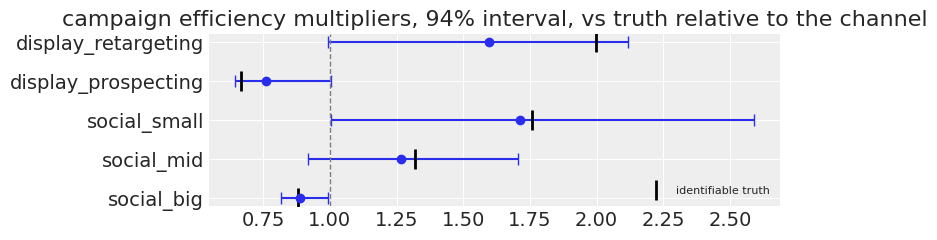

In [4]:
mult = mmm.idata.posterior["nested_media_beta_multiplier"]
q = mult.quantile([0.03, 0.5, 0.97], dim=("chain", "draw"))

fig, ax = plt.subplots(figsize=(8, 2.5))
y_pos = np.arange(len(campaigns))
ax.errorbar(
    q.sel(quantile=0.5),
    y_pos,
    xerr=[
        q.sel(quantile=0.5) - q.sel(quantile=0.03),
        q.sel(quantile=0.97) - q.sel(quantile=0.5),
    ],
    fmt="o",
    capsize=4,
)
ax.set_yticks(y_pos, campaigns)
ax.plot(true_relative, y_pos, "k|", ms=14, mew=2, label="identifiable truth")
ax.axvline(1.0, color="gray", ls="--", lw=1)
ax.legend(loc="lower right", fontsize=8)
ax.set_title(
    "campaign efficiency multipliers, 94% interval, vs truth relative to the channel"
)
fig.tight_layout()

## Decomposition: campaigns, and the channel roll-up

Three deterministics expose the decomposition without touching `mu`:

- `nested_media_campaign_contribution` — per campaign, the object this whole exercise is about;
- `nested_media_channel_contribution` — campaigns summed back to their channel, so channel ROI stays reportable;
- `nested_media_effect_contribution` — the total that enters `mu` (the `MuEffect` contract).

/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_24639/1703301832.py:33: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


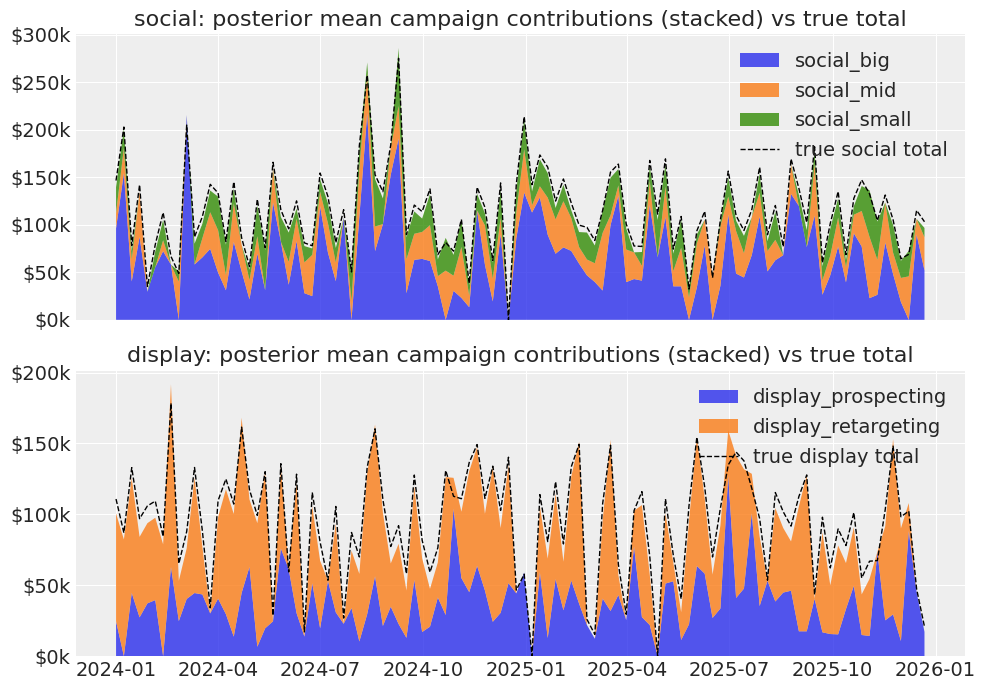

In [5]:
post = mmm.idata.posterior
target_scale = float(mmm.scalers._target)
camp_contrib = (
    post["nested_media_campaign_contribution"].mean(("chain", "draw")) * target_scale
)

# one panel per decomposed channel; the dashed line is that channel's true total
channels = {
    "social": (social_campaigns, contrib_camp),
    "display": (display_campaigns, contrib_display),
}
fig, axes = plt.subplots(len(channels), 1, figsize=(10, 7), sharex=True)
for ax, (channel, (names, true_contrib)) in zip(axes, channels.items(), strict=True):
    ax.stackplot(
        dates,
        [camp_contrib.sel(campaign=c).values for c in names],
        labels=names,
        alpha=0.8,
    )
    ax.plot(
        dates,
        true_contrib.sum(1),
        color="black",
        lw=1,
        ls="--",
        label=f"true {channel} total",
    )
    ax.legend(loc="upper right")
    ax.yaxis.set_major_formatter(dollars)
    ax.set_title(
        f"{channel}: posterior mean campaign contributions (stacked) vs true total"
    )
fig.tight_layout()

In [6]:
# realized ROI per campaign (revenue per dollar over the window): posterior vs truth
spend_window = campaign_spend.sum(0)
denom = np.where(spend_window > 0, spend_window, 1.0)
true_roi = np.column_stack([contrib_camp, contrib_display]).sum(0) / denom
# model contributions are in scaled-target units; convert back with the target scale
target_scale = float(mmm.scalers._target)
post_roi = (
    post["nested_media_campaign_contribution"].sum("date")
    * target_scale
    / xr.DataArray(denom, dims="campaign")
)
summary = pd.DataFrame(
    {
        "channel": [mapping[c] for c in campaigns],
        "spend share": np.r_[shares, display_shares],
        "spend ($, window)": spend_window.round(0),
        "true ROI": true_roi.round(2),
        "posterior ROI": post_roi.mean(("chain", "draw")).values.round(2),
        "posterior sd": post_roi.std(("chain", "draw")).values.round(2),
    },
    index=campaigns,
)
summary

,channel,spend share,"spend ($, window)",true ROI,posterior ROI,posterior sd
social_big,social,0.7,3865322.0,1.99,1.81,0.14
social_mid,social,0.2,957877.0,2.70,2.78,0.45
social_small,social,0.1,414225.0,4.22,4.55,0.90
display_prospecting,display,0.6,1421159.0,2.81,2.72,0.31
display_retargeting,display,0.4,832215.0,7.03,6.44,0.47


## The campaign saturation curves

The decomposition above is the time-series consequence; the *mechanism* is one saturation curve per campaign — the **channel curve scaled by campaign size on both axes**:

$$\text{contribution}_c(x) = \text{cap}_c^{\rho} \cdot m_c \cdot S\!\left(\frac{x}{\text{cap}_c^{\rho} \cdot s_c}\right),$$

where $S$ is the shared channel-level saturation (Michaelis–Menten by default; any `SaturationTransformation` from the library plugs in via the `saturation=` field) and $m_c$, $s_c$ the campaign amplitude and x-scale multipliers. This degree-1 homogeneity in size is deliberate: it makes the parameterisation *split-invariant* (splitting a campaign into proportional halves, the same shares every date, leaves the channel contribution unchanged) and makes **marginal returns equal across campaigns at proportional spend** — so any marginal difference you see below had to be earned from data, not smuggled in by the parameterisation. Two reading rules:

- The shaded band on each curve marks the campaign's **observed operating range** (5–95% of its non-zero weekly spends). Inside it, the curve is informed by data; outside it, you are reading the functional form and the priors, not evidence.
- The dot marks the mean operating point. What matters for decisions is the **slope at that dot** — the marginal ROI — not the height of the curve, and marginal ROIs of campaigns whose operating ranges don't overlap are not directly comparable.

/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_24639/3871827173.py:69: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


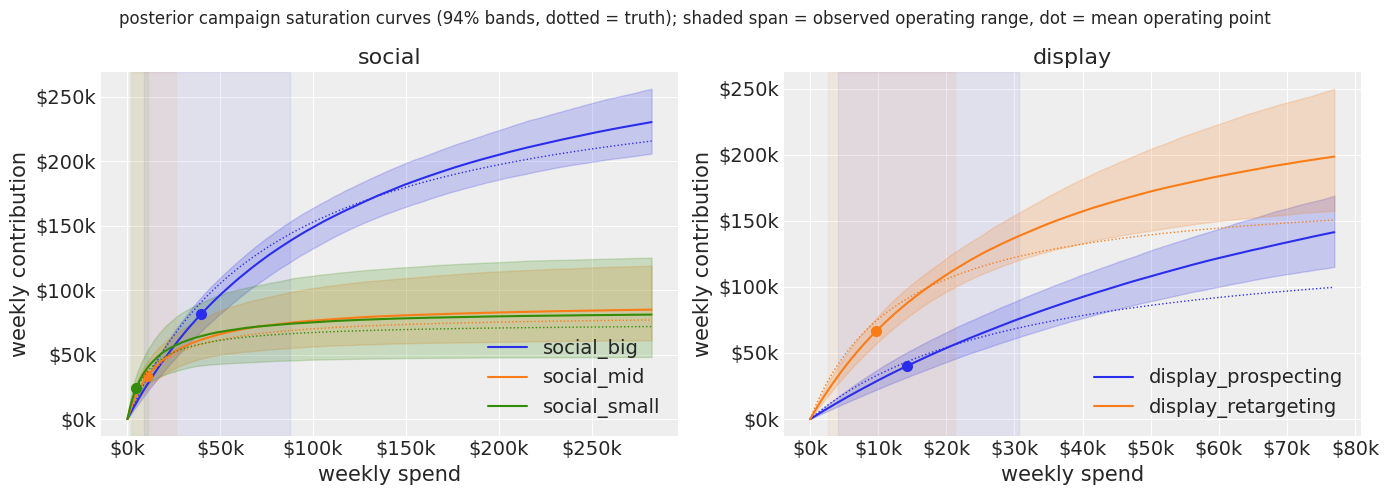

In [7]:
beta_c_post = post["nested_media_beta_campaign"]
lam_c_post = post["nested_media_lam_campaign"]

# per decomposed channel: campaigns, raw spend, channel scale, caps, true curve
curve_setup = {
    "social": (
        social_campaigns,
        social_spend,
        s_social,
        lambda j, xg: (
            revenue_scale
            * (1.2 * true_beta_mult[j])
            * cap[j]
            * xg
            / (xg + 0.35 * cap[j])
        ),
    ),
    "display": (
        display_campaigns,
        display_spend,
        s_display,
        lambda j, xg: (
            revenue_scale
            * 0.6
            * true_display_mult[j]
            * cap_d[j]
            * xg
            / (xg + 0.5 * cap_d[j])
        ),
    ),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (channel, (names, spend, s_channel, true_curve)) in zip(
    axes, curve_setup.items(), strict=True
):
    x_grid = np.linspace(0, spend.max() * 1.2, 200)  # raw weekly spend
    xg = x_grid / s_channel  # the model works on channel-scaled spend
    for j, c in enumerate(names):
        b = beta_c_post.sel(campaign=c).values.ravel()[:, None]
        lam = lam_c_post.sel(campaign=c).values.ravel()[:, None]
        curves = b * xg[None, :] / (xg[None, :] + lam) * target_scale
        med = np.median(curves, axis=0)
        lo, hi = np.percentile(curves, [3, 97], axis=0)

        (line,) = ax.plot(x_grid, med, label=c)
        ax.fill_between(x_grid, lo, hi, alpha=0.2, color=line.get_color())

        live = spend[spend[:, j] > 0, j]
        ax.axvspan(
            np.percentile(live, 5),
            np.percentile(live, 95),
            color=line.get_color(),
            alpha=0.07,
        )
        x0 = live.mean()
        ax.plot(x0, np.interp(x0, x_grid, med), "o", color=line.get_color(), ms=7)
        ax.plot(x_grid, true_curve(j, xg), color=line.get_color(), ls=":", lw=1)
    ax.set_xlabel("weekly spend")
    ax.set_ylabel("weekly contribution")
    ax.xaxis.set_major_formatter(dollars)
    ax.yaxis.set_major_formatter(dollars)
    ax.set_title(f"{channel}")
    ax.legend(loc="lower right")
fig.suptitle(
    "posterior campaign saturation curves (94% bands, dotted = truth); "
    "shaded span = observed operating range, dot = mean operating point"
)
fig.tight_layout()

The size tie is visible immediately: `social_small` both saturates earlier *and* plateaus lower than `social_big` (its curve is the channel curve shrunk by its cap on both axes), and it is more uncertain — the band widens quickly outside its narrow operating range. The dotted truth curves stay inside the bands where there is support and can drift outside them where there is none: exactly the honest behavior we want.

The decision quantity is the slope at each campaign's own operating point, $\beta_c \lambda_c / (x_0 + \lambda_c)^2$ — this is what the `BudgetOptimizer` equalizes across cells at an interior optimum:

In [8]:
rows = {}
for channel, (names, spend, s_channel, _) in curve_setup.items():
    for j, c in enumerate(names):
        live = spend[spend[:, j] > 0, j]
        x0 = live.mean() / s_channel
        b = beta_c_post.sel(campaign=c)
        lam = lam_c_post.sel(campaign=c)
        # d contribution / d raw spend, in target units per spend unit
        marginal = b * lam / (x0 + lam) ** 2 * target_scale / s_channel
        rows[c] = {
            "channel": channel,
            "mean weekly spend ($)": round(float(live.mean())),
            "marginal ROI (median)": round(float(marginal.median()), 2),
            "3%": round(float(marginal.quantile(0.03)), 2),
            "97%": round(float(marginal.quantile(0.97)), 2),
        }
pd.DataFrame(rows).T

,channel,mean weekly spend ($),marginal ROI (median),3%,97%
social_big,social,39849,1.53,1.38,1.68
social_mid,social,10763,1.92,1.42,2.44
social_small,social,4761,3.54,2.3,4.79
display_prospecting,display,14212,2.47,2.03,2.93
display_retargeting,display,9677,5.2,4.5,5.82


At proportional spend the size-tied parameterisation makes marginal ROIs *equal by construction* — so the spread in this table is earned from data: the social marginal ROIs order as the true 1 : 1.5 : 2 efficiencies, not as the sizes, and `display_retargeting`'s advantage tracks its true 3×. (An earlier draft of this effect tied only the half-saturation to size, not the amplitude; marginal ROIs then scaled like 1/share and a 2%-share campaign looked ~35× better at the margin from the parameterisation alone — precisely the kind of artifact a budget optimizer would happily act on. The split-invariance property is now enforced by a test.)

## Where the information comes from (and when it doesn't)

A caution before celebrating: this worked because the synthetic spends had **mix variation**. In a falsification experiment where the three campaigns keep fixed 70/20/10 proportions every single week, the same 2× efficiency is **invisible**: the posterior multipliers collapse to the pooled channel mean, exactly as identification theory predicts — a split that preserves the channel mix carries no campaign-level signal.

Two practical consequences:

1. Check your spend matrix for contrasts (share variance, dark weeks) *before* promising campaign-level answers.
2. When historical contrasts are missing, bring the information from outside — covariates (the `covariate_var` field) or, best of all, **lift tests**.

## Bringing information from outside: per-campaign covariates

Platform exports carry more than spend: impressions, clicks, reach per campaign. `covariate_var` lets a per-campaign table enter the amplitude multiplier. Three steps take a platform export into the model, and each gets its own cell below:

1. **The export.** One row per campaign with spend, impressions and clicks over the training window. This is the table every ad platform hands you.
2. **The covariate.** Pick a metric with an efficiency reading, here clicks per euro, take its log, and shape it as one row per campaign and one column per covariate, with dims `(campaign, covariate)`. The effect centres each column on its channel's spend-share-weighted mean at build time, so what enters the model is *log click efficiency relative to the channel*: it can reallocate efficiency between a channel's campaigns but cannot move the channel total.
3. **The dataset.** Add the table to `X` under any name and point `covariate_var` at it.

Be clear about what a covariate is. **Clicks are not incrementality**, so log clicks per euro is a *hypothesis* about efficiency, not evidence of it. Its coefficient `gamma` is the trust dial: on the log scale, `gamma = 1` reads "sales efficiency follows click efficiency one for one" and `gamma = 0` "ignore it". Where the spend mix varies, the data estimates `gamma`. Where it does not (the fixed-share regime above), `gamma` stays at its prior, so the prior (`gamma_mu`, `gamma_sigma`) is where you state how far you trust the platform signal.

The experiment uses the fixed 70/20/10 regime for `social`, where the multipliers are invisible from sales alone, and fits three models: no covariate, a covariate with the default no-direction prior, and a covariate with a stated trust.

In [9]:
# the fixed-share regime: social keeps 70/20/10 every week, so there is no mix
# variation; the other channels are unchanged
fixed_spend = social_weekly * shares[None, :] * rng.lognormal(0, 0.7, n_dates)[:, None]
xc_fixed = fixed_spend / fixed_spend.sum(1).max()
cap_fixed = xc_fixed.max(0)
contrib_fixed = (
    revenue_scale
    * (1.2 * true_beta_mult)
    * cap_fixed
    * xc_fixed
    / (xc_fixed + 0.35 * cap_fixed)
)
target_fixed = (
    revenue_scale * 0.3
    + contrib_search
    + contrib_tv
    + contrib_fixed.sum(1)
    + contrib_display.sum(1)
    + revenue_scale * rng.normal(0, 0.08, n_dates)
)
all_spend = np.column_stack([fixed_spend, display_spend])
X_fixed = X.assign(campaign_data=(("date", "campaign"), all_spend))
y_fixed = xr.DataArray(target_fixed, dims=("date",), coords={"date": dates})

In [10]:
# step 1: the platform export, one row per campaign over the training window.
# Simulated here: impressions follow spend at a channel CPM, and the click-through
# rate follows the true efficiency (with noise), which is the hypothesis a click
# covariate encodes. In practice this table comes straight from the platform.
cpm = {"social": 8.0, "display": 3.0}  # euro per 1000 impressions
base_ctr = {"social": 0.012, "display": 0.004}
true_mult = dict(zip(campaigns, np.r_[true_beta_mult, true_display_mult], strict=True))
export_rows = []
for j, c in enumerate(campaigns):
    channel = mapping[c]
    spend = all_spend[:, j].sum()
    impressions = 1000 * spend / cpm[channel]
    ctr = base_ctr[channel] * true_mult[c] * np.exp(rng.normal(0, 0.15))
    export_rows.append(
        {
            "campaign": c,
            "channel": channel,
            "spend": round(spend),
            "impressions": int(impressions),
            "clicks": int(impressions * ctr),
        }
    )
platform_export = pd.DataFrame(export_rows).set_index("campaign")
platform_export

,channel,spend,impressions,clicks
campaign,,,,
social_big,social,3697494,462186769,5632696
social_mid,social,1056427,132053362,2235144
social_small,social,528213,66026681,1742421
display_prospecting,display,1421159,473719548,1872301
display_retargeting,display,832215,277404908,3267216


In [11]:
# step 2: from the export to a covariate. Clicks per euro on the log scale; one
# row per campaign, one column per covariate, dims ("campaign", "covariate").
log_clicks_per_euro = np.log(platform_export["clicks"] / platform_export["spend"])
platform = xr.DataArray(
    log_clicks_per_euro.to_numpy()[:, None],
    dims=("campaign", "covariate"),
    coords={"campaign": campaigns, "covariate": ["log_clicks_per_euro"]},
)

# step 3: attach it to the dataset; `covariate_var="platform"` points the effect at it
X_fixed = X_fixed.assign(platform=platform)

# what the effect will see: each value centred on its channel's spend-share-weighted
# mean, so social_small reads as "log 2 above its channel", not as an absolute rate
share_in_channel = platform_export["spend"] / platform_export.groupby("channel")[
    "spend"
].transform("sum")
channel_mean = (
    (share_in_channel * log_clicks_per_euro)
    .groupby(platform_export["channel"])
    .transform("sum")
)
pd.DataFrame(
    {
        "channel": platform_export["channel"],
        "log clicks per euro": log_clicks_per_euro.round(2),
        "centred within channel": (log_clicks_per_euro - channel_mean).round(2),
        "exp(centred)": np.exp(log_clicks_per_euro - channel_mean).round(2),
    }
)

,channel,log clicks per euro,centred within channel,exp(centred)
campaign,,,,
social_big,social,0.42,-0.14,0.87
social_mid,social,0.75,0.19,1.20
social_small,social,1.19,0.63,1.88
display_prospecting,display,0.28,-0.40,0.67
display_retargeting,display,1.37,0.69,1.99


The last column is the number the model actually uses. With the trust prior at `gamma = 1`, `exp(centred)` is where the prior *centres* each campaign's efficiency multiplier: compare it with the black truth ticks in the next figure: the two agree up to the click noise, for both channels.

In [12]:
def fit(X_, y_, df_lift=None, **effect_kwargs):
    """Build and sample an MMM with the nested effect on (X_, y_)."""
    effect = NestedMediaEffect(child_to_parent=mapping, **effect_kwargs)
    model = MMM(
        channel_columns=["search", "tv"],
        date_column="date",
        target_column="y",
        adstock=GeometricAdstock(l_max=2),
        saturation=LogisticSaturation(),
    ).add_mu_effect(effect)
    model.build_model(X=X_, y=y_)
    if df_lift is not None:
        effect.add_lift_test_measurements(df_lift, model)
    with model.model:
        return pm.sample(
            draws=500,
            tune=1000,
            chains=4,
            target_accept=0.9,
            random_seed=seed,
            progressbar=False,
        )


runs = {
    "no covariate": fit(X_fixed, y_fixed),
    "covariate, no direction: gamma ~ N(0, 0.5)": fit(
        X_fixed, y_fixed, covariate_var="platform"
    ),
    "covariate, trusted: gamma ~ N(1, 0.25)": fit(
        X_fixed, y_fixed, covariate_var="platform", gamma_mu=1.0, gamma_sigma=0.25
    ),
}

NUTS[nutpie]: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, nested_media_tau_beta, nested_media_tau_lam, nested_media_z_beta_social, nested_media_z_beta_display, nested_media_z_lam_social, nested_media_z_lam_display, nested_media_saturation_alpha, nested_media_saturation_lam, y_sigma]


NUTS[nutpie]: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, nested_media_tau_beta, nested_media_tau_lam, nested_media_z_beta_social, nested_media_z_beta_display, nested_media_z_lam_social, nested_media_z_lam_display, nested_media_gamma, nested_media_saturation_alpha, nested_media_saturation_lam, y_sigma]


NUTS[nutpie]: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, nested_media_tau_beta, nested_media_tau_lam, nested_media_z_beta_social, nested_media_z_beta_display, nested_media_z_lam_social, nested_media_z_lam_display, nested_media_gamma, nested_media_saturation_alpha, nested_media_saturation_lam, y_sigma]


/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_24639/1640535259.py:34: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


,q03,median,q97
"covariate, no direction: gamma ~ N(0, 0.5)",-0.52,0.24,0.97
"covariate, trusted: gamma ~ N(1, 0.25)",0.47,0.91,1.31


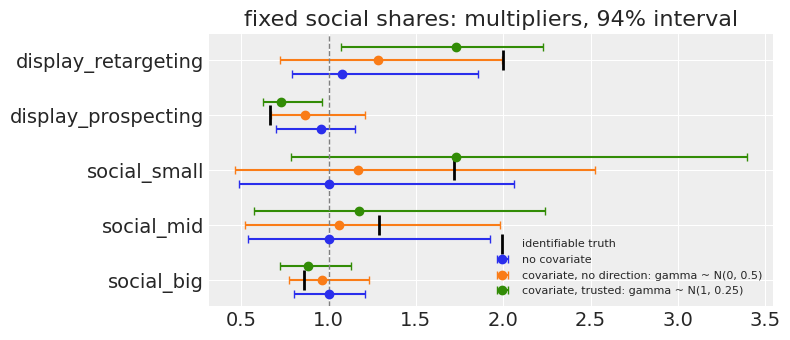

In [13]:
def plot_multipliers(ax, fits, truth, title):
    """Forest plot of the campaign multipliers of several fits against the truth."""
    offsets = np.linspace(-0.25, 0.25, len(fits)) if len(fits) > 1 else [0.0]
    for (label, idata), off in zip(fits.items(), offsets, strict=True):
        q = idata.posterior["nested_media_beta_multiplier"].quantile(
            [0.03, 0.5, 0.97], dim=("chain", "draw")
        )
        ax.errorbar(
            q.sel(quantile=0.5),
            y_pos + off,
            xerr=[
                q.sel(quantile=0.5) - q.sel(quantile=0.03),
                q.sel(quantile=0.97) - q.sel(quantile=0.5),
            ],
            fmt="o",
            capsize=3,
            label=label,
        )
    ax.plot(truth, y_pos, "k|", ms=14, mew=2, label="identifiable truth")
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.set_yticks(y_pos, campaigns)
    ax.legend(loc="lower right", fontsize=8)
    ax.set_title(title)


true_relative_fixed = np.r_[
    relative_multipliers(true_beta_mult, fixed_spend),
    relative_multipliers(true_display_mult, display_spend),
]
fig, ax = plt.subplots(figsize=(8, 3.5))
plot_multipliers(
    ax, runs, true_relative_fixed, "fixed social shares: multipliers, 94% interval"
)
fig.tight_layout()

pd.DataFrame(
    {
        label: run.posterior["nested_media_gamma"]
        .quantile([0.03, 0.5, 0.97], dim=("chain", "draw"))
        .values.ravel()
        for label, run in runs.items()
        if "nested_media_gamma" in run.posterior
    },
    index=["q03", "median", "q97"],
).T.round(2)

Three readings, one per row of the legend.

1. **No covariate.** The multipliers sit at 1 with wide intervals: the falsification result, now shown rather than asserted. Fixed shares carry no campaign-level signal.
2. **Covariate with the default prior.** The coefficient posterior stays close to its prior (the table): the fixed-share social data cannot pin it down. It is not exactly the prior, because `gamma` is shared across channels and `display`, whose shares do vary, lends it a little identification; that is the one way a covariate can learn from one channel and speak for another. For `social` the multipliers only *widen* along the covariate direction. A zero-mean prior states no direction, so a covariate on its own adds spread, not knowledge.
3. **Covariate with a stated trust.** With `gamma ~ N(1, 0.25)` the multipliers move to the click-implied values, close to the truth ticks, while the coefficient again stays at its prior. The information came from the prior you wrote down, not from the data, and the model is honest about it.

This is the same trust dial as the credibility weight in {ref}`mmm_credibility_disaggregation`, where trust in a campaign's platform numbers is set by the people it reached. Here trust is one number you state, and it is *earned* only by mix variation (which lets the data estimate `gamma`) or by a lift test, which is the subject of the next section. Two practical rules follow: keep covariates on an interpretable scale so the prior mean has a meaning, and never let a trusted covariate stand in for a lift test on the campaign you are about to fund.

### Where the mix varies, the covariate tightens

The widening above is easy to misread as "covariates make identification worse". Nothing is identified in the fixed-share regime in any of the three fits; a covariate adds a new unknown, its coefficient, and the posterior width reports the prior you put on it. The test of whether a covariate *helps* is the regime where the data can estimate its coefficient. Below, the main dataset (mix variation) is refit with the trusted click covariate, and the 94% interval widths are compared with the main fit. The covariate table is reused as is: clicks per euro is a rate, so it does not depend on which spend series produced the export.

NUTS[nutpie]: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, nested_media_tau_beta, nested_media_tau_lam, nested_media_z_beta_social, nested_media_z_beta_display, nested_media_z_lam_social, nested_media_z_lam_display, nested_media_gamma, nested_media_saturation_alpha, nested_media_saturation_lam, y_sigma]


/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_24639/10076462.py:13: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


,mix variation only (the main fit),mix variation + trusted covariate,ratio
campaign,,,
social_big,0.18,0.10,0.56
social_mid,0.79,0.53,0.67
social_small,1.59,1.06,0.67
display_prospecting,0.36,0.18,0.51
display_retargeting,1.13,0.83,0.74


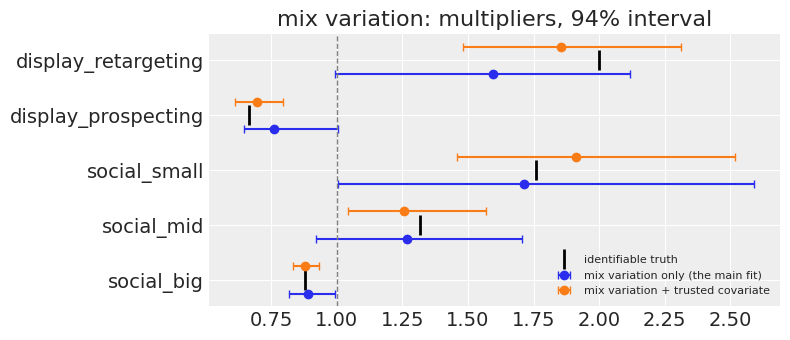

In [14]:
varied = {
    "mix variation only (the main fit)": mmm.idata,
    "mix variation + trusted covariate": fit(
        X.assign(platform=platform),
        y,
        covariate_var="platform",
        gamma_mu=1.0,
        gamma_sigma=0.25,
    ),
}
fig, ax = plt.subplots(figsize=(8, 3.5))
plot_multipliers(ax, varied, true_relative, "mix variation: multipliers, 94% interval")
fig.tight_layout()


def interval_width(idata):
    q = idata.posterior["nested_media_beta_multiplier"].quantile(
        [0.03, 0.97], dim=("chain", "draw")
    )
    return (q.sel(quantile=0.97) - q.sel(quantile=0.03)).to_series()


widths = pd.DataFrame({label: interval_width(idata) for label, idata in varied.items()})
widths["ratio"] = widths.iloc[:, 1] / widths.iloc[:, 0]
widths.round(2)

With mix variation present the covariate coefficient is estimated from sales, and the multipliers tighten (the `ratio` column is below 1) while staying on the truth ticks. So the rule is: a covariate sharpens an answer the data can already give, and states a prior where it cannot. It never manufactures identification.

## Calibrating with a campaign-level lift test

A lift test is direct experimental evidence on one campaign's curve, independent of flighting. `add_lift_test_measurements` conditions the model on the measured incremental response `delta_y` of a spend change `delta_x` at operating point `x`, in spend and target units (the campaign's channel scale and the target scale are handled internally).

The demonstration uses the fixed-share regime once more, where nothing in the sales data can tell `social_small` from its channel, and adds one lift test on `social_small`. The measurement is simulated from the true curve at the campaign's operating point with 10% measurement noise, which is what a well-run geo or conversion-lift experiment would report.

    campaign      x  delta_x  delta_y  sigma
social_small 5079.0   2539.0   6056.0  606.0


NUTS[nutpie]: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, nested_media_tau_beta, nested_media_tau_lam, nested_media_z_beta_social, nested_media_z_beta_display, nested_media_z_lam_social, nested_media_z_lam_display, nested_media_saturation_alpha, nested_media_saturation_lam, y_sigma]


/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_24639/577915148.py:38: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


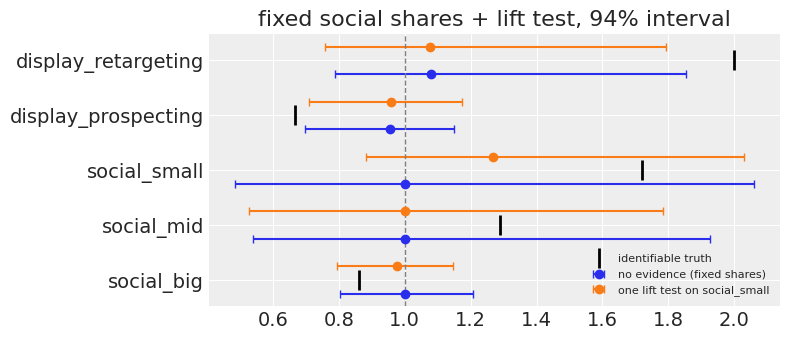

In [15]:
s_fixed = fixed_spend.sum(1).max()  # the social channel scale in the fixed regime


def true_social_small(x):
    """Return social_small's true contribution at raw weekly spend x (fixed regime)."""
    xc_ = x / s_fixed
    return (
        revenue_scale
        * (1.2 * true_beta_mult[2])
        * cap_fixed[2]
        * xc_
        / (xc_ + 0.35 * cap_fixed[2])
    )


x0 = fixed_spend[:, 2].mean()  # operating point: the campaign's mean weekly spend
dx = 0.5 * x0  # the tested increase
delta_y = true_social_small(x0 + dx) - true_social_small(x0)
df_lift = pd.DataFrame(
    {
        "campaign": ["social_small"],
        "x": [x0],
        "delta_x": [dx],
        "delta_y": [delta_y],
        "sigma": [0.10 * delta_y],
    }
)
print(df_lift.round(0).to_string(index=False))  # dollars

lift_runs = {
    "no evidence (fixed shares)": runs["no covariate"],
    "one lift test on social_small": fit(X_fixed, y_fixed, df_lift=df_lift),
}
fig, ax = plt.subplots(figsize=(8, 3.5))
plot_multipliers(
    ax, lift_runs, true_relative_fixed, "fixed social shares + lift test, 94% interval"
)
fig.tight_layout()

One experiment on one campaign moves `social_small` off the pooled mean and toward its truth tick, and its siblings shift with it because the weighted zero sum must close: evidence about one campaign is evidence about the split. It gets about halfway with a single noisy increment, which is the honest amount. One increment at one spend level pins the *slope* there, and a campaign's deviation from its channel is spread over two multipliers, amplitude and x-scale, so one slope cannot settle both. A second measurement at a different spend level, or a tighter experiment, would close the gap.

This is the difference between a lift test and a covariate. The covariate told the model what to believe; the lift test told it what happened.

## Allocating between campaigns

The `BudgetOptimizer` co-optimizes the campaigns with the remaining channels: pass `spend_vars=["campaign_data"]` and every campaign becomes a budget cell competing with `search` and `tv` under one total-budget constraint. Three things to know:

- Use `response_variable="total_response_original_scale"` — the default objective is built from the channel contribution alone and cannot see `MuEffect` contributions (the optimizer raises at construction if you forget).
- The optimizer validates at construction that the response depends on every spend var, so a miswired objective fails loudly instead of silently starving the campaigns.
- `mmm.budget_optimizer(start, end, ...)` builds the optimization-window model for you by **cloning the fitted model**, so the effect's channel scales carry over from training automatically.

In [16]:
historical = pd.Series(
    np.r_[search_spend.mean(), tv_spend.mean(), campaign_spend.mean(0)] * 8,
    index=["search", "tv", *campaigns],
)
optimizer = mmm.budget_optimizer(
    start_date=dates[-1] + pd.Timedelta(weeks=1),
    end_date=dates[-1] + pd.Timedelta(weeks=8),
    spend_vars=["campaign_data"],
    response_variable="total_response_original_scale",
)
result = optimizer.allocate_budget(total_budget=float(historical.sum()))
# channel cells are the media budgets; spend-var cells are keyed by name
campaign_allocation = result.optimized_vars["campaign_data"]
optimal = pd.concat(
    [result.budgets.to_series(), campaign_allocation.to_series()]
).rename("optimal 8-week budget")
optimal.round(0)

/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_24639/3039524468.py:11: UserWarning: No budget bounds provided. Using default bounds (0, total_budget) for each channel.
  result = optimizer.allocate_budget(total_budget=float(historical.sum()))


search                 176424.0
tv                     328514.0
social_big             489405.0
social_mid             108857.0
social_small            88441.0
display_prospecting    504960.0
display_retargeting    264478.0
Name: optimal 8-week budget, dtype: float64

social_small share of the social budget: historical 7.9% -> optimized 12.9%
display_retargeting share of the display budget: historical 36.9% -> optimized 34.4% (cap share, the no-evidence point: 29.4%)


/var/folders/7q/tb5r85wd19l3fplnxjyfdn7r0000gp/T/ipykernel_24639/1592966581.py:14: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


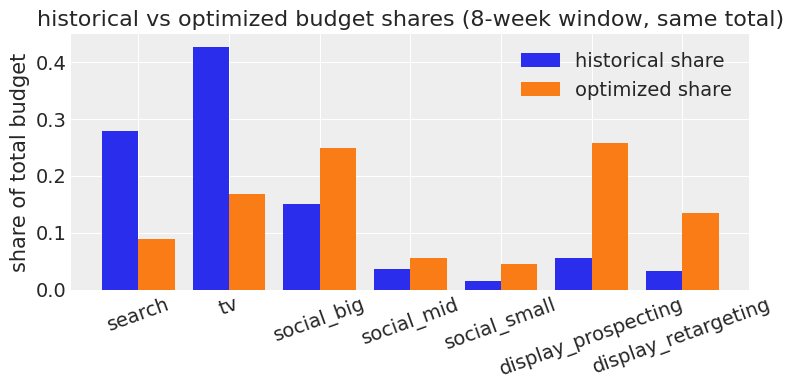

In [17]:
cells = list(optimal.index)
historical = historical.reindex(cells)
hist_share = historical / historical.sum()
opt_share = optimal / optimal.sum()

fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(cells))
ax.bar(x_pos - 0.2, hist_share, width=0.4, label="historical share")
ax.bar(x_pos + 0.2, opt_share, width=0.4, label="optimized share")
ax.set_xticks(x_pos, cells, rotation=20)
ax.set_ylabel("share of total budget")
ax.set_title("historical vs optimized budget shares (8-week window, same total)")
ax.legend()
fig.tight_layout()

social_opt = optimal[social_campaigns]
display_opt = optimal[display_campaigns]
print(
    f"social_small share of the social budget: "
    f"historical {social_spend.mean(0)[2] / social_spend.mean(0).sum():.1%} "
    f"-> optimized {social_opt['social_small'] / social_opt.sum():.1%}"
)
print(
    f"display_retargeting share of the display budget: "
    f"historical {display_spend.mean(0)[1] / display_spend.mean(0).sum():.1%} "
    f"-> optimized {display_opt['display_retargeting'] / display_opt.sum():.1%} "
    f"(cap share, the no-evidence point: {cap_d[1] / cap_d.sum():.1%})"
)

The optimizer moves budget within `social` toward `social_small` — the campaign whose marginal ROI at its operating point was highest in the table above. At an interior optimum those marginal ROIs are equalized across all cells, `search` and `tv` included (this is verified to ~4e-5 relative spread in our stress tests).

Read the reallocation with the same honesty as the fit. Because the parameterisation is size-tied, its no-evidence allocation is *neutral*: in the falsification regime discussed earlier — fixed shares, no campaign-level evidence — the posterior multipliers collapse to 1 and the optimized share stays at the historical one (we measure 10.4% vs 10%). So the movement you see here in `social_small`'s share of the social budget is *earned by the recovered multiplier*, not smuggled in by structure.

One structural term is worth separating out before crediting evidence. The no-evidence point of the size-tied parameterisation is proportional to each campaign's *cap* (its maximum channel-scaled spend, the size measure behind $\text{cap}_c^{\rho}$), and with lognormal flighting the ratio of maxima drifts from the average split; the printout above shows that cap share next to the historical and optimized shares. In the fixed-share falsification the cap share equals the average share, which is why that experiment reads as "stays at history". With flighting, a reallocation decomposes into *history → structure (the cap share) → evidence (the multipliers)*, and only the last step is a statement about efficiency. `display_retargeting` shows both at once: its cap share is ~29% against a realised ~37% of the display budget, so structure alone would move it *down*, and the recovered 3× advantage brings it back to ~36%. Read the small net change as two large opposing terms, not as "nothing happened". The remaining discipline still applies: treat allocations far outside a campaign's operating range as extrapolation.

## Current limitations

- `MMM.save`/`load` does not round-trip the effect yet (the reload path rebuilds `X` as a DataFrame, which cannot carry the `campaign` dimension). Tracked as a strict `xfail`.
- No campaign-level adstock yet; carryover currently comes only from the channel-level part of the model.
- A pre-fit identifiability diagnostic (formalizing the "check your contrasts" advice above) is planned.

Recovery evidence for the pooling claim (20-seed paired study, weak-data regime): the nested effect beats flat no-pooling on 2%-share campaigns in 20/20 seeds, median error ratio 3.78×.

In [18]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Thu, 17 Sep 2026

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.17.1

pymc_marketing: 1.1.0
pytensor      : 3.2.4

arviz         : 1.3.0
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 3.0.5
pymc          : 6.2.0
pymc_marketing: 1.1.0
xarray        : 2026.7.0

Watermark: 2.6.0

